# LangChain 멀티모달리티(Multimodality) - v1.0 

---

## 1. 멀티모달리티 개요

- **멀티모달리티(Multimodality)** 는 텍스트, 이미지, 오디오, 비디오 등 다양한 형태의 데이터를 처리하는 기술

- **LangChain의 주요 멀티모달 컴포넌트:**

    - **채팅 모델(Chat Models)**: 다양한 입출력 형식 처리
    - **임베딩 모델(Embedding Models)**: 다양한 데이터 타입의 벡터 표현
    - **벡터 저장소(Vector Stores)**: 멀티모달 데이터의 임베딩 검색


---

## 2. 표준 콘텐츠 블록 (Standard Content Blocks)

### 2.1 메시지 콘텐츠 형식

- LangChain 채팅 모델은 `content` 속성에서 다음 세 가지 형식을 지원합니다:

    1. **문자열**: 단순 텍스트 메시지
    2. **프로바이더 네이티브 포맷**: 프로바이더별 형식
    3. **표준 콘텐츠 블록**: LangChain 표준 형식 (권장 ✅)

        ```python
        from langchain.messages import HumanMessage

        # 1. 문자열 콘텐츠
        message1 = HumanMessage("안녕하세요")

        # 2. 프로바이더 네이티브 포맷 (OpenAI)
        message2 = HumanMessage(content=[
            {"type": "text", "text": "안녕하세요"},
            {"type": "image_url", "image_url": {"url": "https://example.com/image.jpg"}}
        ])

        # 3. 표준 콘텐츠 블록 (권장)
        message3 = HumanMessage(content_blocks=[
            {"type": "text", "text": "안녕하세요"},
            {"type": "image", "url": "https://example.com/image.jpg"}
        ])
        ```

### 2.2 `content_blocks` 속성

- 모든 메시지 객체는 `content_blocks` 속성을 통해 **표준화된 타입 안전 표현**에 접근 가능

    ```python
    from langchain.chat_models import init_chat_model

    model = init_chat_model("gpt-4o")
    response = model.invoke("AI에 대해 설명해주세요")

    # content_blocks를 통한 표준화된 접근
    for block in response.content_blocks:
        if block["type"] == "text":
            print(block["text"])
        elif block["type"] == "reasoning":
            print(f"추론 과정: {block['reasoning']}")
    ```

---

## 3. 멀티모달 콘텐츠 블록 타입

### 3.1 지원하는 콘텐츠 블록 타입

- **Core 블록**

    | 타입 | 설명 | 주요 필드 |
    |------|------|-----------|
    | `text` | 표준 텍스트 출력 | `text`, `annotations` |
    | `reasoning` | 모델 추론 단계 | `reasoning` |

<br>

- **Multimodal 블록**

    | 타입 | 설명 | 주요 필드 |
    |------|------|-----------|
    | `image` | 이미지 데이터 | `url`, `base64`, `id`, `mime_type` |
    | `audio` | 오디오 데이터 | `url`, `base64`, `id`, `mime_type` |
    | `video` | 비디오 데이터 | `url`, `base64`, `id`, `mime_type` |
    | `file` | 일반 파일 (PDF 등) | `url`, `base64`, `id`, `mime_type` |
    | `text-plain` | 문서 텍스트 (.txt, .md) | `text`, `mime_type` |

<br>

- **Tool Calling 블록**

    | 타입 | 설명 |
    |------|------|
    | `tool_call` | 함수 호출 |
    | `tool_call_chunk` | 스트리밍 도구 호출 단편 |
    | `invalid_tool_call` | 잘못된 도구 호출 |

### 3.2 데이터 전달 방식

- **URL 방식**

    ```python
    image_block = {
        "type": "image",
        "url": "https://example.com/image.jpg",
        "mime_type": "image/jpeg"
    }
    ```

    - **장점:**
        - 간단하고 직관적
        - 대용량 파일에 유리

    - **단점:**
        - 외부 접근 가능한 URL 필요
        - 네트워크 의존성

- **Base64 인코딩 방식 (권장)**

    ```python
    import base64

    def encode_image_to_base64(image_path: str) -> str:
        """이미지를 base64로 인코딩"""
        with open(image_path, "rb") as image_file:
            return base64.b64encode(image_file.read()).decode("utf-8")

    image_block = {
        "type": "image",
        "base64": encode_image_to_base64("photo.jpg"),
        "mime_type": "image/jpeg"
    }
    ```

    - **장점:**
        - 가장 안정적
        - URL 불필요
        - 모든 프로바이더 지원

    - **단점:**
        - 토큰 사용량 증가

- **File ID 방식 (프로바이더 관리)**

    ```python
    image_block = {
        "type": "image",
        "file_id": "file-abc123",  # 프로바이더가 관리하는 파일 ID
    }
    ```

    - **장점:**
        - 토큰 효율적
        - 재사용 가능

    - **단점:**
        - 프로바이더별 사전 업로드 필요
        - 제한적 지원

---

## 4. 이미지 처리 실습

### 4.1 환경 설정

`(1) Env 환경변수`

In [ ]:
from dotenv import load_dotenv
load_dotenv()

True

`(2) 기본 라이브러리`

In [ ]:
import os
import base64
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

import warnings
warnings.filterwarnings('ignore')

`(3) langfuase handler 설정`

In [ ]:
from langfuse.langchain import CallbackHandler

# 콜백 핸들러 생성
langfuse_handler = CallbackHandler()

### 4.2 모델 초기화 (v1.0 방식)

In [ ]:
# init_chat_model 사용 (권장)
model = init_chat_model(
    "gpt-4o-mini",  # 멀티모달 지원 모델
    temperature=0
)

In [ ]:
# 또는 특정 프로바이더 클래스 사용
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

### 4.3 URL 방식 이미지 처리

In [ ]:
def process_image_from_url(image_url: str, prompt: str):
    """URL에서 직접 이미지 처리 (v1.0 표준 콘텐츠 블록)"""
    
    message = HumanMessage(content_blocks=[
        {"type": "text", "text": prompt},
        {"type": "image", "url": image_url, "mime_type": "image/jpeg"}
    ])
    
    return model.invoke([message])

# 실행 예시
image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
result = process_image_from_url(image_url, "이미지를 상세히 설명해주세요")
print(result.content)

이미지에는 두 마리의 고양이가 소파 위에서 편안하게 잠을 자고 있는 모습이 담겨 있습니다. 소파는 밝은 핑크색으로, 고양이들은 서로 다른 자세로 누워 있습니다. 

왼쪽에 있는 고양이는 길고 날씬한 몸매를 가지고 있으며, 등을 대고 누워서 다리를 쭉 뻗고 있습니다. 털은 줄무늬가 있으며, 귀에는 작은 리본 같은 장식이 보입니다. 

오른쪽에 있는 고양이는 좀 더 통통한 체형으로, 옆으로 누워서 머리를 아래로 향하고 있습니다. 이 고양이의 털은 다양한 색조의 갈색과 검정색이 섞여 있습니다. 

소파 위에는 리모컨이 여러 개 놓여 있어, 고양이들이 편안하게 쉬고 있는 분위기를 더해줍니다. 전체적으로 아늑하고 평화로운 느낌을 주는 장면입니다.


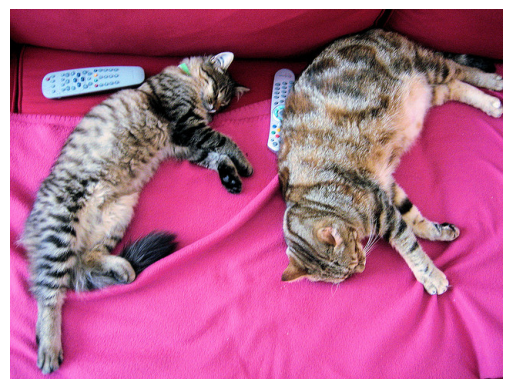

In [ ]:
# URL이 입력된 경우를 지원하는 이미지 출력 함수
import requests
from io import BytesIO
import matplotlib.pyplot as plt
from PIL import Image

def show_image(image_path):
    if isinstance(image_path, str) and image_path.startswith("http"):
        # URL에서 이미지 다운로드
        headers = {
            'User-Agent': 'Mozilla/5.0'
        }
        response = requests.get(image_path, headers=headers)
        response.raise_for_status()
        image = Image.open(BytesIO(response.content))
    else:
        image = Image.open(image_path)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

show_image(image_url)

### 4.4 Base64 방식 이미지 처리

In [ ]:
def encode_image_to_base64(image_path: str) -> str:
    """로컬 이미지를 base64로 인코딩"""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

def encode_image_url_to_base64(image_url: str) -> str:
    """URL 이미지를 base64로 인코딩"""
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
    }
    response = requests.get(image_url, headers=headers)
    response.raise_for_status()
    return base64.b64encode(response.content).decode('utf-8')

def process_image_with_base64(image_source: str, prompt: str):
    """Base64로 이미지 처리 (v1.0 표준 콘텐츠 블록)"""
    
    # 이미지를 base64로 변환
    if image_source.startswith("http"):
        image_data = encode_image_url_to_base64(image_source)
    else:
        image_data = encode_image_to_base64(image_source)
    
    message = HumanMessage(content_blocks=[
        {"type": "text", "text": prompt},
        {
            "type": "image",
            "base64": image_data,
            "mime_type": "image/jpeg"
        }
    ])
    
    return model.invoke([message])

# 실행 예시
result = process_image_with_base64("portrait.jpg", "이 초상화의 특징을 분석해주세요")
print(result.content)

이 초상화는 빈센트 반 고흐의 자화상으로, 여러 가지 특징이 있습니다.

1. **색채 사용**: 반 고흐는 강렬하고 대조적인 색상을 사용하여 감정을 표현합니다. 배경의 푸른색과 인물의 따뜻한 피부톤 및 붉은 수염이 뚜렷한 대비를 이루고 있습니다.

2. **붓질**: 그의 독특한 붓질이 잘 드러나며, 짧고 굵은 터치로 질감을 강조합니다. 이는 작품에 생동감을 부여합니다.

3. **표정**: 인물의 표정은 강렬하고 집중된 느낌을 주며, 고흐의 내면의 갈등이나 감정을 반영하는 듯합니다.

4. **구성**: 인물은 화면의 중앙에 배치되어 있으며, 시선이 관객을 직접 바라보는 구도로, 강한 몰입감을 제공합니다.

5. **의상**: 어두운 색상의 외투는 인물의 얼굴을 더욱 돋보이게 하며, 고흐의 개인적인 스타일을 나타냅니다.

이 초상화는 고흐의 예술적 정체성과 감정을 잘 드러내는 작품으로 평가받고 있습니다.


### 4.5 여러 이미지 동시 처리

In [ ]:
def process_multiple_images(image_sources: list, prompt: str):
    """여러 이미지를 동시에 처리 (v1.0 표준 콘텐츠 블록)"""
    
    # 콘텐츠 블록 리스트 시작 (프롬프트)
    content_blocks = [{"type": "text", "text": prompt}]
    
    # 각 이미지를 콘텐츠 블록에 추가
    for image_source in image_sources:
        if image_source.startswith("http"):
            # URL 처리
            image_data = encode_image_url_to_base64(image_source)
            content_blocks.append({
                "type": "image",
                "base64": image_data,
                "mime_type": "image/jpeg"
            })
        else:
            # Base64 직접 처리
            image_data = encode_image_to_base64(image_source)
            content_blocks.append({
                "type": "image",
                "base64": image_data,
                "mime_type": "image/jpeg"
            })
    
    message = HumanMessage(content_blocks=content_blocks)
    return model.invoke([message])

# 실행 예시
images = [
    "portrait.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/600px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg"
]

result = process_multiple_images(
    images,
    "이 두 작품을 비교 분석해주세요. 화풍, 색채, 구도의 차이점을 중심으로 설명해주세요."
)
print(result.content)

두 작품은 빈센트 반 고흐의 대표작으로, 각각 자화상과 "별이 빛나는 밤"입니다. 이 두 작품을 화풍, 색채, 구도의 차이점을 중심으로 비교 분석해 보겠습니다.

### 화풍
1. **자화상**: 반 고흐의 자화상은 강렬한 붓질과 점묘법을 사용하여 감정과 내면을 표현합니다. 그의 얼굴 표정과 턱수염, 머리카락의 질감이 뚜렷하게 드러나며, 감정적인 깊이를 전달합니다.
   
2. **별이 빛나는 밤**: 이 작품은 더 유동적이고 역동적인 화풍을 보여줍니다. 하늘의 소용돌이치는 구름과 별들이 강렬한 움직임을 만들어내며, 자연의 힘과 신비로움을 강조합니다. 

### 색채
1. **자화상**: 색채는 주로 따뜻한 색조로 구성되어 있으며, 붉은 머리카락과 수염, 그리고 어두운 외투가 대비를 이루어 인물의 감정을 강조합니다. 배경은 차가운 색조로, 인물의 감정과 대조를 이루고 있습니다.

2. **별이 빛나는 밤**: 이 작품은 주로 차가운 파란색과 노란색의 대비가 두드러집니다. 밤하늘의 깊은 파란색과 밝은 별, 달이 서로를 보완하며, 신비로운 분위기를 자아냅니다.

### 구도
1. **자화상**: 인물 중심의 구도로, 반 고흐의 얼굴이 화면의 중앙에 위치하여 관객의 시선을 즉각적으로 끌어옵니다. 배경은 단순하지만, 인물의 감정에 집중할 수 있게 합니다.

2. **별이 빛나는 밤**: 이 작품은 복잡한 구도로, 하늘과 땅이 조화를 이루며 깊이감을 제공합니다. 전경의 나무와 마을, 그리고 하늘의 소용돌이가 서로 연결되어 있으며, 시선이 자연스럽게 하늘로 이어지도록 유도합니다.

### 결론
이 두 작품은 반 고흐의 독특한 화풍과 감정 표현을 잘 보여줍니다. 자화상은 개인의 내면을 탐구하는 반면, "별이 빛나는 밤"은 자연의 신비로움과 우주적 감정을 표현합니다. 색채와 구도의 차이는 각 작품의 주제와 감정을 더욱 강조하는 역할을 합니다.


---

## 5. 다양한 멀티모달 타입 처리

### 5.1 PDF 문서 처리

In [ ]:
def process_pdf_document(pdf_source: str, prompt: str):
    """PDF 문서 처리 (v1.0 표준 콘텐츠 블록)"""
    
    if pdf_source.startswith("http"):
        # URL 방식
        content_blocks = [
            {"type": "text", "text": prompt},
            {"type": "file", "url": pdf_source, "mime_type": "application/pdf"}
        ]
    else:
        # Base64 방식
        with open(pdf_source, "rb") as pdf_file:
            pdf_data = base64.b64encode(pdf_file.read()).decode("utf-8")
        
        content_blocks = [
            {"type": "text", "text": prompt},
            {
                "type": "file",
                "base64": pdf_data,
                "mime_type": "application/pdf",
                # 일부 프로바이더는 파일명 필요
                "extras": {"filename": "리비안_KR_with_table.pdf"}
            }
        ]
    
    message = HumanMessage(content_blocks=content_blocks)
    return model.invoke([message])

# 실행 예시
result = process_pdf_document(
    "data/리비안_KR_with_table.pdf",
    "이 문서의 주요 내용을 요약해주세요"
)

print(result.content)

리비안(Rivian Automotive, Inc.)은 2009년에 설립된 미국의 전기 자동차 제조업체로, 전기 SUV, 픽업 트럭 및 상업용 전기 밴을 생산합니다. 주요 내용은 다음과 같습니다:

### 회사 개요
- **설립**: 2009년, 플로리다 주 록리지
- **본사**: 캘리포니아 주 어바인
- **CEO**: R. J. 스캐린지
- **상장**: NASDAQ: RIVN
- **2023년 생산량**: 57,232대
- **2023년 수익**: 44억 3천만 달러, 순손실 54억 달러

### 제품 및 서비스
- **주요 제품**: R1T(픽업 트럭), R1S(SUV), Rivian EDV(전기 배달 밴)
- **충전 네트워크**: 미국과 캐나다에 공공 충전소 개발 중, 2023년부터 Rivian 외 차량에도 개방 예정

### 역사
- **초기(2009-2015)**: 스포츠카 프로토타입에서 전기 및 자율주행 차량으로 전환
- **생산 준비(2016-2020)**: 2017년 제조 공장 인수 및 R1T, R1S 공개
- **IPO 및 확장(2021-2024)**: 2021년 R1T 배송 시작, 135억 달러 IPO, 여러 파트너십 및 가격 인상 발표

### 재정
- **2023년 총 자산**: 168억 달러
- **주요 주주**: Amazon, T. Rowe Price, The Vanguard Group 등

### 협력 및 소송
- 다양한 환경 및 스포츠 관련 파트너십을 맺고 있으며, Tesla와의 소송 및 소비자 직접 판매 관련 소송이 있었습니다.

리비안은 전기차 시장에서의 입지를 강화하고 있으며, 지속적인 기술 개발과 파트너십을 통해 성장하고 있습니다.


### 5.2 오디오 처리

In [ ]:
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage
import base64

# 오디오 지원 모델
gemini_model = init_chat_model(
    "google_genai:gemini-2.5-flash",
    temperature=0,
)

def process_audio(audio_source: str, prompt: str = "이 오디오를 텍스트로 변환해주세요"):
    """
    최신 langchain 메시지 content_blocks 규격 적용.
    :param audio_source: 로컬 오디오 파일 경로 또는 http url
    :param prompt: 프롬프트 메시지
    :return: 텍스트 변환 결과
    """

    if audio_source.startswith("http"):
        content_blocks = [
            {"type": "text", "text": prompt},
            {"type": "audio", "url": audio_source, "mime_type": "audio/mpeg"}
        ]
    else:
        with open(audio_source, "rb") as audio_file:
            audio_data = base64.b64encode(audio_file.read()).decode("utf-8")
        content_blocks = [
            {"type": "text", "text": prompt},
            {
                "type": "audio",
                "base64": audio_data,
                "mime_type": "audio/mpeg"
            }
        ]

    message = HumanMessage(content_blocks=content_blocks)
    result = gemini_model.invoke([message])
    return result  # AIMessage 타입, .content_blocks 또는 .content 사용 가능

# 실행 예시
result = process_audio(
    "data/meeting_sample.mp3", 
    "이 오디오를 텍스트로 변환해주세요"
    )
print(result.content)

네, 여보세요. 아, 예, 안녕하세요. 저는  예, 감사합니다. 네.


### 5.3 비디오 처리

In [ ]:
# 비디오 지원 모델
gemini_model = init_chat_model(
    "google_genai:gemini-2.5-flash",
    temperature=0,
)

def process_video(video_source: str, prompt: str):
    """비디오 처리 (v1.0 표준 콘텐츠 블록)"""
    
    if video_source.startswith("http"):
        content_blocks = [
            {"type": "text", "text": prompt},
            {"type": "video", "url": video_source, "mime_type": "video/mp4"}
        ]
    else:
        with open(video_source, "rb") as video_file:
            video_data = base64.b64encode(video_file.read()).decode("utf-8")
        
        content_blocks = [
            {"type": "text", "text": prompt},
            {
                "type": "video",
                "base64": video_data,
                "mime_type": "video/mp4"
            }
        ]
    
    message = HumanMessage(content_blocks=content_blocks)
    return gemini_model.invoke([message])

# 실행 예시
result = process_video(
    "data/bikes.mp4", 
    "이 비디오에서 일어나는 주요 이벤트를 시간순으로 설명해주세요"
    )

print(result.content)

이 비디오에서 일어나는 주요 이벤트는 다음과 같습니다:

*   **00:00 - 00:12**: 비디오는 오토바이 운전자의 1인칭 시점으로 시작됩니다. 오토바이는 댐이나 제방으로 보이는 길을 따라 직진하고 있습니다. 왼쪽에는 넓은 수면이 보이고, 오른쪽에는 숲이 우거진 언덕이 있습니다. 운전자의 손은 핸들바를 잡고 있으며, 계기판이 보입니다. 이따금 운전자의 오른손이 핸들바에서 잠시 떨어졌다가 다시 잡는 모습이 보입니다.
*   **00:12 - 00:22**: 약 00:12부터 도로는 오른쪽으로 완만하게 굽어지기 시작합니다. 오토바이는 이 곡선 구간을 따라 주행하며, 비디오는 오토바이가 여전히 커브를 돌고 있는 상태에서 끝납니다.


---

## 6. 표준 콘텐츠 직렬화

- 표준 콘텐츠 블록은 기본적으로 `content` 속성에 직렬화되지 **않습니다**. 
- 외부 애플리케이션에서 표준 콘텐츠 블록 표현이 필요한 경우 별도의 **직렬화** 처리가 필요합니다.

    - **사용해야 할 때**

        - API 엔드포인트 구현
        - 프론트엔드와 통신
        - 멀티 프로바이더 지원
        - 로깅/분석 시스템
        - JSON 직렬화 필요

    - **불필요한 경우**

        - 내부 처리만 수행
        - 단일 프로바이더만 사용
        - 최대 성능 필요



- **핵심 개념**

    ```python
    # 기본 동작 (output_version 미설정)
    response.content         → 프로바이더 네이티브 형식 (예: 문자열)
    response.content_blocks  → LangChain 표준 형식 (항상)

    # 직렬화 활성화 (output_version="v1")
    response.content         → LangChain 표준 형식 ✅
    response.content_blocks  → LangChain 표준 형식 ✅

    # 결과
    response.content == response.content_blocks  # True
    ```


- **비교표**

    | 항목 | 기본 | 직렬화 활성화 |
    |------|------|---------------|
    | `content` 형식 | 프로바이더별 | 표준 |
    | `content_blocks` 형식 | 표준 | 표준 |
    | 프로바이더 전환 | 코드 수정 필요 | 불필요 |
    | 성능 | ⚡ 빠름 | 약간 느림 |
    | 외부 통합 | 어려움 | 쉬움 |



In [ ]:
# 직렬화 없이 사용하는 경우 (기존 방법)
model = init_chat_model("gpt-4o-mini")
response = model.invoke("AI를 설명해주세요")
print(response.content)  # 프로바이더 네이티브 형식

AI, 즉 인공지능(Artificial Intelligence)은 컴퓨터 시스템이나 기계가 인간의 지능을 모방하거나 구현하는 기술을 의미합니다. AI는 주로 데이터를 처리하고, 학습하며, 문제를 해결하는 능력을 바탕으로 작동합니다. AI의 주요 분류는 다음과 같습니다.

1. **약한 AI(Weak AI)**: 특정 작업이나 문제를 해결하기 위해 설계된 AI로, 일반적인 지능을 갖고 있지 않습니다. 예를 들어, 음성 인식 시스템이나 추천 알고리즘 등이 이에 해당합니다.

2. **강한 AI(Strong AI)**: 인간과 유사한 수준의 이해력과 사고능력을 갖춘 인공지능으로, 아직 실현되지 않았습니다. 강한 AI는 스스로 문제를 해결하고, 학습하며, 창의적인 작업을 수행할 수 있도록 설계됩니다.

AI 기술에는 머신러닝(Machine Learning)과 딥러닝(Deep Learning) 같은 하위 분야가 포함됩니다. 머신러닝은 데이터에서 패턴을 학습하여 예측하거나 결정을 내리는 기술이며, 딥러닝은 인공신경망을 기반으로 하는 머신러닝의 한 형태로, 보다 복잡한 데이터 처리에 적합합니다.

AI는 의료, 자율주행차, 자연어 처리, 금융 등 다양한 분야에서 응용되고 있으며, 우리의 일상생활과 산업에 큰 변화를 가져오고 있습니다.


In [ ]:
print(response.content_blocks)  # 표준 형식

[{'type': 'text', 'text': 'AI, 즉 인공지능(Artificial Intelligence)은 컴퓨터 시스템이나 기계가 인간의 지능을 모방하거나 구현하는 기술을 의미합니다. AI는 주로 데이터를 처리하고, 학습하며, 문제를 해결하는 능력을 바탕으로 작동합니다. AI의 주요 분류는 다음과 같습니다.\n\n1. **약한 AI(Weak AI)**: 특정 작업이나 문제를 해결하기 위해 설계된 AI로, 일반적인 지능을 갖고 있지 않습니다. 예를 들어, 음성 인식 시스템이나 추천 알고리즘 등이 이에 해당합니다.\n\n2. **강한 AI(Strong AI)**: 인간과 유사한 수준의 이해력과 사고능력을 갖춘 인공지능으로, 아직 실현되지 않았습니다. 강한 AI는 스스로 문제를 해결하고, 학습하며, 창의적인 작업을 수행할 수 있도록 설계됩니다.\n\nAI 기술에는 머신러닝(Machine Learning)과 딥러닝(Deep Learning) 같은 하위 분야가 포함됩니다. 머신러닝은 데이터에서 패턴을 학습하여 예측하거나 결정을 내리는 기술이며, 딥러닝은 인공신경망을 기반으로 하는 머신러닝의 한 형태로, 보다 복잡한 데이터 처리에 적합합니다.\n\nAI는 의료, 자율주행차, 자연어 처리, 금융 등 다양한 분야에서 응용되고 있으며, 우리의 일상생활과 산업에 큰 변화를 가져오고 있습니다.'}]


In [ ]:
# 직렬화 적용: response.content에 표준 콘텐츠 블록이 직렬화됨
model = init_chat_model("gpt-4o-mini", output_version="v1")
response = model.invoke("AI를 설명해주세요")
print(response.content)  # 표준 형식으로 직렬화됨

[{'type': 'text', 'text': 'AI(인공지능)는 컴퓨터 시스템이나 기계가 인간의 지능을 모방하여 학습, 문제 해결, 이해, 감지 등의 작업을 수행할 수 있도록 하는 기술입니다. AI는 다음과 같은 여러 분야로 나눌 수 있습니다.\n\n1. **기계학습(ML, Machine Learning)**: 데이터로부터 패턴을 학습하여 예측하거나 결정을 내리는 알고리즘입니다. 예를 들어, 스팸 이메일 필터링이나 추천 시스템이 여기에 해당합니다.\n\n2. **딥러닝(Deep Learning)**: 기계학습의 한 분야로, 인공신경망을 사용하여 데이터의 복잡한 패턴을 학습합니다. 이미지 인식, 음성 인식 등이 대표적인 응용 분야입니다.\n\n3. **자연어처리(NLP, Natural Language Processing)**: 컴퓨터가 인간의 언어를 이해하고 생성할 수 있도록 하는 기술입니다. 예를 들어, 챗봇이나 번역기가 여기에 해당합니다.\n\n4. **컴퓨터 비전(Computer Vision)**: 이미지나 비디오 데이터를 분석하여 정보를 추출하거나 이해하는 기술입니다. 객체 인식, 얼굴 인식 등이 이에 포함됩니다.\n\n5. **로봇공학(Robotics)**: AI를 활용하여 물리적 로봇이 주어진 작업을 수행하도록 하는 분야입니다. 로봇 청소기, 자율주행차 등이 그 예입니다.\n\nAI 기술은 다양한 산업과 분야에서 활용되고 있으며, 의료, 금융, 제조 등 여러 영역에서 혁신을 이루고 있습니다. 하지만 AI의 발전에는 윤리적 문제, 데이터 프라이버시, 그리고 일자리의 변화 등의 도전과제가 동반되기도 합니다.'}]


In [ ]:
print(response.content_blocks)  # 표준 형식 

[{'type': 'text', 'text': 'AI(인공지능)는 컴퓨터 시스템이나 기계가 인간의 지능을 모방하여 학습, 문제 해결, 이해, 감지 등의 작업을 수행할 수 있도록 하는 기술입니다. AI는 다음과 같은 여러 분야로 나눌 수 있습니다.\n\n1. **기계학습(ML, Machine Learning)**: 데이터로부터 패턴을 학습하여 예측하거나 결정을 내리는 알고리즘입니다. 예를 들어, 스팸 이메일 필터링이나 추천 시스템이 여기에 해당합니다.\n\n2. **딥러닝(Deep Learning)**: 기계학습의 한 분야로, 인공신경망을 사용하여 데이터의 복잡한 패턴을 학습합니다. 이미지 인식, 음성 인식 등이 대표적인 응용 분야입니다.\n\n3. **자연어처리(NLP, Natural Language Processing)**: 컴퓨터가 인간의 언어를 이해하고 생성할 수 있도록 하는 기술입니다. 예를 들어, 챗봇이나 번역기가 여기에 해당합니다.\n\n4. **컴퓨터 비전(Computer Vision)**: 이미지나 비디오 데이터를 분석하여 정보를 추출하거나 이해하는 기술입니다. 객체 인식, 얼굴 인식 등이 이에 포함됩니다.\n\n5. **로봇공학(Robotics)**: AI를 활용하여 물리적 로봇이 주어진 작업을 수행하도록 하는 분야입니다. 로봇 청소기, 자율주행차 등이 그 예입니다.\n\nAI 기술은 다양한 산업과 분야에서 활용되고 있으며, 의료, 금융, 제조 등 여러 영역에서 혁신을 이루고 있습니다. 하지만 AI의 발전에는 윤리적 문제, 데이터 프라이버시, 그리고 일자리의 변화 등의 도전과제가 동반되기도 합니다.'}]


In [ ]:
%%writefile fastapi_example.py
# encoding: utf-8
from fastapi import FastAPI
from pydantic import BaseModel
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv

load_dotenv()

app = FastAPI()

model = init_chat_model("gpt-4o-mini", output_version="v1")

@app.post("/query")
async def query(text: str):
    response = model.invoke(text)
    
    return {
        "content": response.content,  # ✅ 표준 형식 보장
        "model": "gpt-4o-mini",
        "tokens": response.usage_metadata["total_tokens"]
    }

Writing fastapi_example.py


In [ ]:
# 노트북 셀에서 백그라운드로 실행
import uvicorn
import threading
from fastapi_example import app

def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000)

# 백그라운드 스레드로 실행
server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

import time
time.sleep(2)  # 서버 시작 대기
print("✅ 서버가 http://localhost:8000 에서 실행 중입니다")

INFO:     Started server process [43188]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


✅ 서버가 http://localhost:8000 에서 실행 중입니다


INFO:     127.0.0.1:8582 - "POST /query?text=%EC%9D%B8%EA%B3%B5%EC%A7%80%EB%8A%A5%EC%97%90+%EB%8C%80%ED%95%B4+%EA%B0%84%EB%8B%A8%ED%9E%88+%EC%84%A4%EB%AA%85%ED%95%B4%EC%A3%BC%EC%84%B8%EC%9A%94 HTTP/1.1" 200 OK


In [ ]:
import requests

# POST 요청 테스트
response = requests.post(
    "http://localhost:8000/query",
    params={"text": "인공지능에 대해 간단히 설명해주세요"}
)

print("Status Code:", response.status_code)
print("Response:", response.json())

Status Code: 200
Response: {'content': [{'type': 'text', 'text': '인공지능(AI)은 컴퓨터 시스템이나 기계가 인간의 지능을 모방하여 학습, 추론, 이해, 문제 해결 등의 작업을 수행할 수 있도록 하는 기술입니다. AI는 주로 두 가지로 분류될 수 있습니다:\n\n1. **약한 인공지능(Weak AI)**: 특정 작업을 수행하도록 설계된 시스템으로, 예를 들어 음성 인식 소프트웨어나 추천 시스템 등이 이에 해당합니다.\n\n2. **강한 인공지능(Strong AI)**: 인간과 유사한 수준의 지능을 지니고, 스스로 학습하고 문제를 해결할 수 있는 시스템으로, 아직 완전하게 구현된 것은 아닙니다.\n\nAI는 머신러닝과 딥러닝 같은 기술을 통해 데이터를 분석하고 패턴을 인식하여 자율적으로 개선할 수 있습니다. 이러한 기술은 이미지 인식, 자연어 처리, 자율주행차 등 다양한 분야에서 활용되고 있습니다.'}], 'model': 'gpt-4o-mini', 'tokens': 221}


- 서버 종료

    ```bash
    # 포트 8000을 사용하는 프로세스 찾기
    lsof -ti:8000 | xargs kill -9

    # 또는 (macOS/Linux)
    kill $(lsof -t -i:8000)
    ``

### 7. content_blocks 속성 활용

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    include_thoughts=True,
)

response = llm.invoke("How many 'r's are in the word 'strawberry'?")

for block in response.content_blocks:
    if block["type"] == "text":
        print(f"텍스트: {block['text']}")
    
    elif block["type"] == "reasoning":
        print(f"추론 과정: {block['reasoning']}")


추론 과정: **Calculating the 'R' Count in "Strawberry"**

Okay, so I see the request. It's a pretty straightforward query: count the occurrences of the letter 'r' in the word "strawberry." No problem. Let's break this down systematically.

First, I need to isolate the target letter, which is clearly 'r'.  Then, I've got the word "strawberry," and I just need to scan it. Now, as an expert, I don't need to actually vocalize the individual letters, but I can internally step through the word. *s*... *t*... *r* (okay, one), *a*... *w*... *b*... *e*... *r* (two), *r* (three), and finally, *y*.

Three 'r's!  The word "strawberry" contains three instances of the letter 'r'. I'll formulate my response clearly, making sure the user knows the answer immediately.

텍스트: There are **3** 'r's in the word 'strawberry'.


---

### [실습] LangChain과 Google Gemini를 활용한 멀티모달 애플리케이션 만들기

- **실습 시나리오**
    - 사용자가 이미지를 업로드하면, 이미지의 내용을 간략하게 설명(요약)해주는 파이프라인을 LangChain 기반으로 구현합니다.
    - 또한, 설명 결과와 reasoning(추론 과정) 블록이 함께 출력되게 하세요.

- **필수 구현 요소**
    1. LangChain의 GoogleGenerativeAI 모델(ChatGoogleGenerativeAI)을 사용합니다.
    2. 이미지를 파일로 읽어서 입력 메시지에 multimodal 형식으로 첨부합니다.
    3. 모델의 응답에서 `content_blocks` 속성을 이용해 설명(텍스트)과 reasoning(추론)의 내용을 구분해서 출력하세요.
    4. 적절한 이미지를 준비해서 테스트해보세요.

- **참고**: [ChatGoogleGenerativeAI 문서](https://reference.langchain.com/python/integrations/langchain_google_genai/)


In [ ]:
# Google Gemini 멀티모달 애플리케이션 실습
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.messages import HumanMessage
import base64
import os

# 1. 모델 초기화 (include_thoughts=True로 reasoning 포함)
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    include_thoughts=True,  # reasoning 블록 포함
    temperature=0
)

# 2. 이미지를 base64로 인코딩하는 함수
def encode_image_to_base64(image_path: str) -> str:
    """로컬 이미지를 base64로 인코딩"""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

# 3. 멀티모달 이미지 분석 파이프라인
def analyze_image_with_reasoning(image_path: str, prompt: str = "이 이미지를 간략하게 설명해주세요"):
    """
    이미지를 분석하고 설명과 추론 과정을 출력하는 파이프라인
    
    Args:
        image_path: 이미지 파일 경로
        prompt: 분석 요청 프롬프트
    
    Returns:
        AIMessage 응답 객체
    """
    
    # 이미지 파일 존재 확인
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"이미지 파일을 찾을 수 없습니다: {image_path}")
    
    # 이미지를 base64로 인코딩
    image_data = encode_image_to_base64(image_path)
    
    # content_blocks 형식으로 메시지 생성
    message = HumanMessage(content_blocks=[
        {"type": "text", "text": prompt},
        {
            "type": "image",
            "base64": image_data,
            "mime_type": "image/jpeg"
        }
    ])
    
    # 모델 호출
    response = llm.invoke([message])
    
    return response

# 4. 응답에서 텍스트와 reasoning 분리 출력
def display_response_blocks(response):
    """
    응답의 content_blocks를 순회하며 텍스트와 reasoning을 구분 출력
    
    Args:
        response: AIMessage 응답 객체
    """
    print("=" * 80)
    print("📊 이미지 분석 결과")
    print("=" * 80)
    
    text_count = 0
    reasoning_count = 0
    
    for block in response.content_blocks:
        if block["type"] == "text":
            text_count += 1
            print(f"\n✅ [텍스트 #{text_count}]")
            print(f"{block['text']}")
            print("-" * 80)
        
        elif block["type"] == "reasoning":
            reasoning_count += 1
            print(f"\n🧠 [추론 과정 #{reasoning_count}]")
            print(f"{block['reasoning']}")
            print("-" * 80)
    
    print(f"\n📈 요약: 텍스트 블록 {text_count}개, 추론 블록 {reasoning_count}개")
    print("=" * 80)

# 5. 테스트 실행
try:
    # 테스트할 이미지 경로 (portrait.jpg 또는 다른 이미지)
    test_image_path = "portrait.jpg"
    
    # 이미지가 없으면 URL에서 다운로드
    if not os.path.exists(test_image_path):
        print(f"⚠️ {test_image_path} 파일이 없습니다. URL 이미지를 사용합니다.")
        # URL 이미지 사용 예시
        import requests
        image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
        response = requests.get(image_url, headers={'User-Agent': 'Mozilla/5.0'})
        with open("temp_test_image.jpg", "wb") as f:
            f.write(response.content)
        test_image_path = "temp_test_image.jpg"
    
    # 이미지 분석 실행
    print(f"🖼️ 분석할 이미지: {test_image_path}")
    
    response = analyze_image_with_reasoning(
        test_image_path,
        "이 이미지를 자세히 분석하고 설명해주세요. 주요 객체, 색상, 구도 등을 포함해주세요."
    )
    
    # 결과 출력
    display_response_blocks(response)
    
    # 임시 파일 삭제
    if os.path.exists("temp_test_image.jpg"):
        os.remove("temp_test_image.jpg")
        print("\n🗑️ 임시 파일 삭제 완료")
    
except FileNotFoundError as e:
    print(f"❌ 파일 오류: {e}")
    print("💡 힌트: portrait.jpg 파일을 노트북과 같은 디렉토리에 준비하거나, 코드에서 다른 이미지 경로를 지정하세요.")
    
except Exception as e:
    print(f"❌ 실행 오류: {e}")
    print(f"오류 타입: {type(e).__name__}")
    import traceback
    traceback.print_exc()

🖼️ 분석할 이미지: portrait.jpg
📊 이미지 분석 결과

🧠 [추론 과정 #1]
**Deconstructing the Essence: A Van Gogh Self-Portrait**

Okay, so I'm looking at this Van Gogh self-portrait, and my mind immediately starts to dissect it. First, it's unmistakably Van Gogh – the heavy impasto, the vibrant colors, the almost frenetic energy. I know this style well. The user wants a detailed breakdown, which is exactly what I enjoy doing.

I start by taking in the whole image. It's a self-portrait, a man looking directly at me, the viewer. I see the strong, slightly elongated nose, the direct gaze, and the famous beard, a fiery explosion of orange and red. I think, 'Let's see what's really happening here.'

The figure dominates the composition. I notice the deep, pulsating blue-green background. It's not just a backdrop; it’s an active element, swirling and textured, almost vibrating with energy. The blue creates a strong contrast to the warm tones of the face and beard. The yellow highlights on the face and hair draw 